In [42]:
import pandas as pd
import numpy as np

# ====================================================
# 1단계: 데이터 불러오기 및 날짜 인덱스 세팅
# ====================================================

# 1. 월말 데이터 (가격, 시가총액, 이미 시프트된 PBR)
ac_df = pd.read_csv("수정주가.csv", index_col=0, parse_dates=True)
mkt_cap_df = pd.read_csv("mkt.csv", index_col=0, parse_dates=True)          
pbr_df = pd.read_csv("PBR.csv", index_col=0, parse_dates=True)  #---->lag 필요없음.

# 2. 분기말 재무 데이터 (영업이익, 자산총계)
op_df = pd.read_csv("영업이익.csv", index_col=0, parse_dates=True)   
asset_df = pd.read_csv("자산총계.csv", index_col=0, parse_dates=True)

print("✅ 1단계: 신규 전략 데이터 로드 완료!")
print(f"수정주가 데이터 형태: {ac_df.shape}")
print(f"시가총액 데이터 형태: {mkt_cap_df.shape}")
print(f"PBR 데이터 형태: {pbr_df.shape}")
print(f"영업이익 데이터 형태: {op_df.shape}")
print(f"자산총계 데이터 형태: {asset_df.shape}")

✅ 1단계: 신규 전략 데이터 로드 완료!
수정주가 데이터 형태: (133, 3933)
시가총액 데이터 형태: (135, 3930)
PBR 데이터 형태: (135, 3930)
영업이익 데이터 형태: (46, 3933)
자산총계 데이터 형태: (50, 3933)


In [43]:
asset_df.head(20)

,삼성전자,SK하이닉스,현대차,LG에너지솔루션,한화에어로스페이스,삼성바이오로직스,SK스퀘어,두산에너빌리티,HD현대중공업,기아,...,연합과기,차이나그레이트,중국원양자원,중국식품포장,에스앤씨엔진그룹,차이나하오란,웨이포트,성융광전투자유한공사,완리,골든센츄리
Date,,,,,,,,,,,,,,,,,,,,,
2013-12-31,2.140750e+11,2.079730e+10,1.334215e+11,NaN,3.434224e+09,6.534257e+08,NaN,2.772548e+10,NaN,3.618204e+10,...,NaN,413920016.0,557820728.0,NaN,346300672.0,328971306.0,206734660.0,NaN,352885031.0,NaN
2014-03-31,2.252926e+11,2.206574e+10,1.372828e+11,NaN,3.611280e+09,NaN,NaN,2.823684e+10,NaN,3.798819e+10,...,NaN,460816030.0,560630462.0,NaN,352947478.0,319691847.0,209155851.0,NaN,383406718.0,NaN
2014-06-30,2.247231e+11,2.255671e+10,1.382689e+11,NaN,3.635217e+09,NaN,NaN,2.822447e+10,NaN,3.888402e+10,...,NaN,461695940.0,512109772.0,NaN,337163705.0,319783007.0,212002117.0,NaN,405023726.0,NaN
2014-09-30,2.317465e+11,2.408122e+10,1.413233e+11,NaN,3.652281e+09,NaN,NaN,2.830913e+10,NaN,3.982361e+10,...,NaN,487523206.0,491687438.0,NaN,339130148.0,331947649.0,216656514.0,NaN,424418341.0,NaN
2014-12-31,2.304230e+11,2.688328e+10,1.472251e+11,NaN,3.601728e+09,1.357295e+09,NaN,2.755191e+10,NaN,4.104420e+10,...,NaN,534717426.0,501145840.0,NaN,355414237.0,412087083.0,231478508.0,NaN,409325296.0,58027616.0
2015-03-31,2.272504e+11,2.739291e+10,1.476344e+11,NaN,3.855175e+09,NaN,NaN,2.723740e+10,NaN,4.163331e+10,...,NaN,538330534.0,506973487.0,NaN,370081090.0,406771658.0,277466244.0,NaN,434437395.0,NaN
2015-06-30,2.316909e+11,2.846370e+10,1.536161e+11,NaN,4.174373e+09,NaN,NaN,2.746062e+10,NaN,4.469831e+10,...,NaN,576936900.0,523323692.0,NaN,388960370.0,429674717.0,255063240.0,NaN,512544198.0,NaN
2015-09-30,2.465676e+11,2.934214e+10,1.599855e+11,NaN,3.880834e+09,NaN,NaN,2.853599e+10,NaN,4.563971e+10,...,NaN,599591586.0,527622808.0,NaN,418147858.0,430299760.0,290161555.0,NaN,549033332.0,NaN
2015-12-31,2.421795e+11,2.967791e+10,1.653679e+11,NaN,4.107930e+09,5.960494e+09,NaN,2.726014e+10,NaN,4.598011e+10,...,NaN,592977114.0,559155303.0,NaN,416663801.0,390316514.0,251717032.0,NaN,495216984.0,64444122.0


In [44]:
# ====================================================
# 2단계: 공통 종목 추출, 데이터 시프트 및 3대 팩터 산출 (수정본)
# ====================================================

# 1) 5개 데이터에 모두 존재하는 공통 종목(교집합) 찾기
common_cols = ac_df.columns.intersection(mkt_cap_df.columns)\
                           .intersection(pbr_df.columns)\
                           .intersection(op_df.columns)\
                           .intersection(asset_df.columns)

ac_df = ac_df[common_cols]
mkt_cap_df = mkt_cap_df[common_cols]
pbr_df = pbr_df[common_cols]
op_df = op_df[common_cols]
asset_df = asset_df[common_cols]

# 2) 재무 데이터 월간 확장 및 정밀 시프트(Shift)
op_m = op_df.resample('ME').last()
asset_m = asset_df.resample('ME').last()

# [시프트 적용] 월 단위이므로 1분기 = 3개월
op_shifted_1q = op_m.shift(3).ffill(limit=2)       # 이번 분기 영업이익                     # 문제없음.
asset_shifted_1q = asset_m.shift(3).ffill(limit=2) # 이번 분기 자산                        # 문제없음.
asset_shifted_2q = asset_m.shift(6).ffill(limit=2) # 직전 분기 자산 (P 스코어용)             # 문제없음.
asset_shifted_5q = asset_m.shift(15).ffill(limit=2)# 작년 동분기 자산 (I 스코어용)           # 문제없음.

In [45]:
asset_shifted_5q.head(20)

,삼성전자,SK하이닉스,현대차,LG에너지솔루션,한화에어로스페이스,삼성바이오로직스,SK스퀘어,두산에너빌리티,HD현대중공업,기아,...,연합과기,차이나그레이트,중국원양자원,중국식품포장,에스앤씨엔진그룹,차이나하오란,웨이포트,성융광전투자유한공사,완리,골든센츄리
Date,,,,,,,,,,,,,,,,,,,,,
2013-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
# ----------------------------------------------------
# 3) 3대 팩터 (V, P, I Score) 산출
# ----------------------------------------------------
pbr_m = pbr_df.resample('ME').last()

# PBR 필터 (0.2이하는 NaN 처리하여 제외) 🚨
pbr_m[pbr_m <= 0.2] = pd.NA 

# ① 가치(V) Score: 1 / PBR 
v_raw = 1 / pbr_m

# ② 수익성(P) Score: 이번 분기 영업이익 / 직전 분기 자산
p_raw = op_shifted_1q / asset_shifted_2q

# ③ 보수적 투자(I) Score: 1 / 자산성장률 (작년 동분기 자산 / 이번 분기 자산)
i_raw = asset_shifted_5q / asset_shifted_1q

In [47]:
# ----------------------------------------------------
# 4) 가격, 수익률 및 동전주 필터링 세팅
# ----------------------------------------------------
monthly_prices_raw = ac_df.resample('ME').last()
monthly_prices_ffill = monthly_prices_raw.ffill() # 수익률 계산용 (상폐 방어)

monthly_prices_screen = monthly_prices_raw.copy()
monthly_prices_screen[monthly_prices_screen < 1000] = pd.NA # 동전주 제외

monthly_returns_raw = monthly_prices_raw.pct_change(fill_method=None)
monthly_mkt_cap = mkt_cap_df.resample('ME').last()

print("✅ 2단계: PBR 필터가 추가된 데이터 세팅 완벽 종료!")

✅ 2단계: PBR 필터가 추가된 데이터 세팅 완벽 종료!


In [48]:
# ====================================================
# 3단계: 소형주 필터링, 팩터 랭킹 부여 및 분기 리밸런싱 루프
# ====================================================

# 15개월(5분기) 시프트를 고려하여 첫 리밸런싱은 2015년 6월 30일부터 시작합니다.
bt_month_ends = ac_df.resample('ME').last().loc['2015-03-31':'2025-12-31'].index

portfolio_ret = pd.Series(dtype=float)
portfolio_ret[bt_month_ends[0]] = 0.0

basket = [] 
holdings_history = {} 

# 추가: total_score 저장용 (행=날짜, 열=종목코드)
total_score_panel = pd.DataFrame(index=bt_month_ends, columns=ac_df.columns, dtype=float)

for i in range(0, len(bt_month_ends) - 1):
    start_date = bt_month_ends[i]
    end_date   = bt_month_ends[i + 1]
    
    # [분기말 리밸런싱: 3, 6, 9, 12월]
    if start_date.month in [3, 6, 9, 12] or len(basket) == 0:
        
        # 1. 현재 시점의 팩터 데이터 가져오기
        current_v = v_raw.loc[start_date].astype(float)
        current_p = p_raw.loc[start_date].astype(float)
        current_i = i_raw.loc[start_date].astype(float)
        current_mkt = monthly_mkt_cap.loc[start_date].astype(float)
        current_returns = monthly_returns_raw.loc[start_date]
        
        # --- [1차 필터링: 조건 1, 2, 4, 5 적용] ---
        # ① 동전주 제외 및 PBR 0.2 이하 제외 (2단계에서 NaN 처리 완료됨)
        valid_price = monthly_prices_screen.loc[start_date].dropna().index
        
        # ② 거래정지 제외 (수익률이 정확히 0.0인 종목)
        valid_trading = current_returns[current_returns != 0.0].dropna().index
        
        # ③ 이상치 수익률 제외 (지난 한 달간 +100% 이상 컷, -50% 이하 컷)
        valid_outlier = current_returns[(current_returns < 1.0) & (current_returns > -0.5)].index
        
        # V, P, I 데이터가 모두 정상적으로 존재하는 종목만 교집합 추출
        valid_data = current_v.dropna().index.intersection(current_p.dropna().index)\
                              .intersection(current_i.dropna().index)\
                              .intersection(current_mkt.dropna().index)
        
###################수정한부분#####################################################

        # 1차 유효 유니버스
        universe = valid_price.intersection(valid_trading)\
                              .intersection(valid_outlier)\
                              .intersection(valid_data)
################################################################################
        if len(universe) > 0:
            # --- [2차 필터링: 조건 3 소형주 선별] ---
            # 유효 유니버스 내에서 시가총액 하위 50% (중앙값 이하) 추출
            mkt_universe = current_mkt.loc[universe]
            mkt_median = mkt_universe.median()
            small_cap_universe = mkt_universe[mkt_universe <= mkt_median].index
            
            # --- [팩터 랭킹화 및 통합 점수(Total Score) 계산] ---
            # 0~1 사이의 백분위수 랭킹(pct=True) 부여
            v_rank = current_v.loc[small_cap_universe].rank(pct=True)
            p_rank = current_p.loc[small_cap_universe].rank(pct=True)
            i_rank = current_i.loc[small_cap_universe].rank(pct=True)
            
            # 가점 합산 (가치 + 수익성 + 보수적 투자)
            total_score = v_rank + p_rank + i_rank
            # 해당 날짜 행에 종목별 total_score 저장
            total_score_panel.loc[start_date, total_score.index] = total_score.values
            # --- [최종 TOP 20 선정] ---
                        # --- [최종 상위 20% 선정] ---
            n_buy = max(1, int(len(total_score) * 0.1))
            basket = total_score.nlargest(n_buy).index
        else:
            basket = []
        
        # 편입 종목 기록
        holdings_history[start_date.strftime('%Y-%m-%d')] = basket.tolist() if len(basket) > 0 else []
        print(f"🔄 {start_date.strftime('%Y-%m-%d')} 리밸런싱! (소형주 풀: {len(small_cap_universe)}개 ")

    # [수익률 계산: 상폐 대응용 ffill 주가 사용]
    if len(basket) > 0:
        buy_prices = monthly_prices_ffill.loc[start_date, basket]
        sell_prices = monthly_prices_ffill.loc[end_date, basket]
        returns = ((sell_prices / buy_prices) - 1).mean()
    else:
        returns = 0.0
        
    portfolio_ret.loc[end_date] = returns

print("🎉 V+P+I 소형주 가치투자 백테스트 루프 완료!")

🔄 2015-03-31 리밸런싱! (소형주 풀: 639개 
🔄 2015-06-30 리밸런싱! (소형주 풀: 647개 
🔄 2015-09-30 리밸런싱! (소형주 풀: 653개 
🔄 2015-12-31 리밸런싱! (소형주 풀: 661개 
🔄 2016-03-31 리밸런싱! (소형주 풀: 680개 
🔄 2016-06-30 리밸런싱! (소형주 풀: 686개 
🔄 2016-09-30 리밸런싱! (소형주 풀: 694개 
🔄 2016-12-31 리밸런싱! (소형주 풀: 696개 
🔄 2017-03-31 리밸런싱! (소형주 풀: 714개 
🔄 2017-06-30 리밸런싱! (소형주 풀: 716개 
🔄 2017-09-30 리밸런싱! (소형주 풀: 728개 
🔄 2017-12-31 리밸런싱! (소형주 풀: 726개 
🔄 2018-03-31 리밸런싱! (소형주 풀: 749개 
🔄 2018-06-30 리밸런싱! (소형주 풀: 759개 
🔄 2018-09-30 리밸런싱! (소형주 풀: 768개 
🔄 2018-12-31 리밸런싱! (소형주 풀: 749개 
🔄 2019-03-31 리밸런싱! (소형주 풀: 774개 
🔄 2019-06-30 리밸런싱! (소형주 풀: 777개 
🔄 2019-09-30 리밸런싱! (소형주 풀: 778개 
🔄 2019-12-31 리밸런싱! (소형주 풀: 780개 
🔄 2020-03-31 리밸런싱! (소형주 풀: 734개 
🔄 2020-06-30 리밸런싱! (소형주 풀: 784개 
🔄 2020-09-30 리밸런싱! (소형주 풀: 793개 
🔄 2020-12-31 리밸런싱! (소형주 풀: 807개 
🔄 2021-03-31 리밸런싱! (소형주 풀: 837개 
🔄 2021-06-30 리밸런싱! (소형주 풀: 839개 
🔄 2021-09-30 리밸런싱! (소형주 풀: 854개 
🔄 2021-12-31 리밸런싱! (소형주 풀: 849개 
🔄 2022-03-31 리밸런싱! (소형주 풀: 866개 
🔄 2022-06-30 리밸런싱! (소형주 풀: 868개 
🔄 2022-09-

In [49]:
# total_score가 한 번도 계산되지 않은 행 제거
total_score_panel = total_score_panel.dropna(how="all")

# CSV 저장
total_score_panel.to_csv("total_score_panel_wide.csv", encoding="utf-8-sig")

print("✅ 저장 완료: total_score_panel_wide.csv")
print(total_score_panel.head())

✅ 저장 완료: total_score_panel_wide.csv
            삼성전자  SK하이닉스  현대차  LG에너지솔루션  한화에어로스페이스  삼성바이오로직스  SK스퀘어  두산에너빌리티  \
Date                                                                           
2015-03-31   NaN     NaN  NaN       NaN        NaN       NaN    NaN      NaN   
2015-06-30   NaN     NaN  NaN       NaN        NaN       NaN    NaN      NaN   
2015-09-30   NaN     NaN  NaN       NaN        NaN       NaN    NaN      NaN   
2015-12-31   NaN     NaN  NaN       NaN        NaN       NaN    NaN      NaN   
2016-03-31   NaN     NaN  NaN       NaN        NaN       NaN    NaN      NaN   

            HD현대중공업  기아  ...  연합과기  차이나그레이트  중국원양자원  중국식품포장  에스앤씨엔진그룹  \
Date                     ...                                            
2015-03-31      NaN NaN  ...   NaN      NaN     NaN     NaN  2.342723   
2015-06-30      NaN NaN  ...   NaN      NaN     NaN     NaN  2.307573   
2015-09-30      NaN NaN  ...   NaN      NaN     NaN     NaN       NaN   
2015-12-31      NaN NaN  ...   NaN    

In [50]:
# ====================================================
# [점검용] 매 분기 리밸런싱 시점별 이상치(Outlier) 탈락 종목 확인
# ====================================================

# 점검할 기간 세팅
check_dates = ac_df.resample('ME').last().loc['2015-06-30':'2025-12-31'].index

print("🔍 [수익률 이상치(Outlier) 필터 탈락 종목 점검]")
print("-" * 50)

total_outliers_count = 0

for start_date in check_dates:
    if start_date.month in [3, 6, 9, 12]:
        current_returns = monthly_returns_raw.loc[start_date]
        
        # 수익률 데이터가 있는 종목만 1차로 추림 (NaN 제외)
        valid_returns = current_returns.dropna()
        
        # 🚨 탈락 조건: 수익률 1.0(100%) 이상이거나 -0.5(-50%) 이하인 종목
        outliers = valid_returns[(valid_returns >= 1.0) | (valid_returns <= -0.5)]
        
        if len(outliers) > 0:
            total_outliers_count += len(outliers)
            print(f"📅 {start_date.strftime('%Y-%m-%d')} | 탈락 종목 수: {len(outliers)}개")
            
            # 어떤 종목이 몇 % 수익률로 탈락했는지 상세 출력
            for stock, ret in outliers.items():
                print(f"   - {stock}: {ret * 100:.1f}%")
        else:
            print(f"📅 {start_date.strftime('%Y-%m-%d')} | 이상치 탈락 종목 없음")

print("-" * 50)
print(f"총 누적 이상치 탈락 횟수: {total_outliers_count}회")

🔍 [수익률 이상치(Outlier) 필터 탈락 종목 점검]
--------------------------------------------------
📅 2015-06-30 | 탈락 종목 수: 9개
   - 한미사이언스: 116.2%
   - 삼양홀딩스: 115.7%
   - 대화제약: 105.9%
   - 남광토건: 156.4%
   - 에쓰씨엔지니어링: 146.1%
   - 옴니시스템: 105.9%
   - 인크레더블버즈: 102.9%
   - (주)에스마크: 118.1%
   - 참존글로벌(주): 166.7%
📅 2015-09-30 | 탈락 종목 수: 8개
   - 오리엔탈정공: -57.9%
   - 동부건설: 155.2%
   - 한국전자인증: 139.2%
   - 애머릿지: 437.7%
   - 광림: 102.4%
   - 쌍방울: 241.1%
   - (주)썬테크놀로지스: 141.9%
   - (주)코썬바이오: -66.7%
📅 2015-12-31 | 탈락 종목 수: 8개
   - 한중엔시에스: -50.7%
   - 서원: 106.9%
   - 써니전자: 162.1%
   - THE E&M: 245.4%
   - 메이슨캐피탈: -55.0%
   - 에이루트: 171.5%
   - 엔피케이: 131.9%
   - (주)코원플레이: 119.4%
📅 2016-03-31 | 탈락 종목 수: 11개
   - 디에스케이: 173.8%
   - 코데즈컴바인: 230.1%
   - 진양산업: 114.5%
   - 폴라리스세원: -68.0%
   - 진양화학: 142.1%
   - 엠젠솔루션: 132.5%
   - 플루토스: 118.1%
   - 링크드: 227.9%
   - 스튜디오산타클로스: 220.2%
   - 광림: 143.2%
   - (주)엔에스브이: -56.4%
📅 2016-06-30 | 탈락 종목 수: 9개
   - 차AI헬스케어: 145.1%
   - 코데즈컴바인: -77.4%
   - 지엘팜텍: 131.5%
   - 동방선기: -55.9%
   - 

📊 [소형주 퀄리티 가치투자(V+P+I) 전략 성과 요약] 📊
연평균 수익률(CAGR): 16.74%
연환산 변동성(Ann.Vol): 21.24%
최대 낙폭(MDD):   -26.36%
샤프 비율(Sharpe): 0.75
--------------------------------------------------


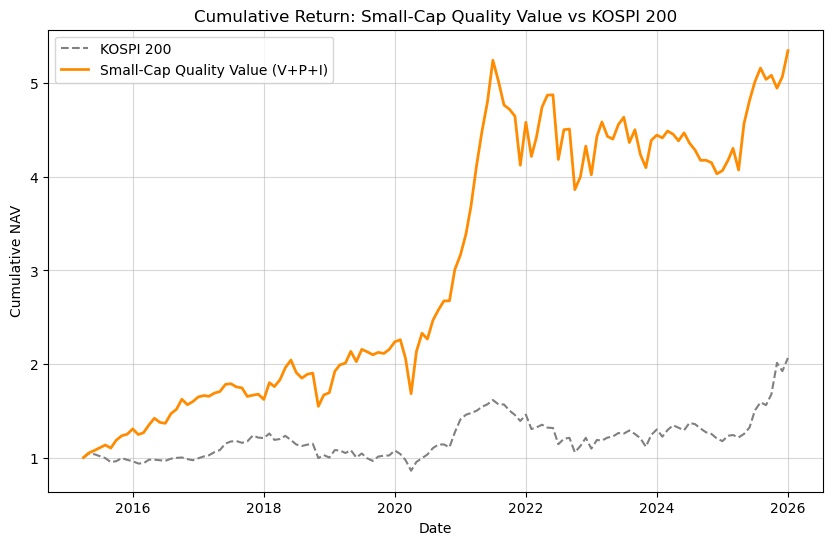

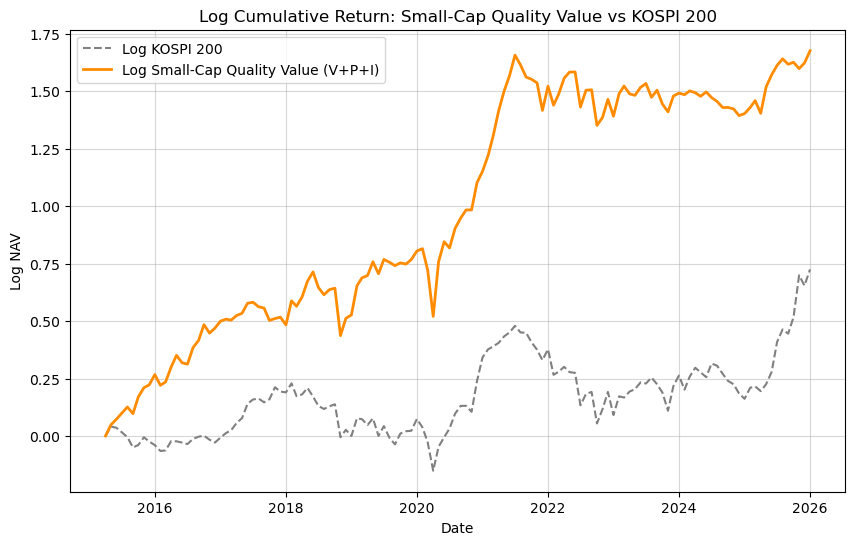

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# ====================================================
# 4단계: 누적 수익률(NAV), 성과 지표(CAGR, MDD, Sharpe) 및 시각화
# ====================================================

# 1) 포트폴리오 누적 수익률 계산
portfolio_nav = (1 + portfolio_ret).cumprod()

# 2) 벤치마크(KOSPI 200) 데이터 불러오기
factor  = pd.read_csv("Factor.csv", index_col=0, parse_dates=True)
KOSPI   = factor[["KOSPI"]]

# 포트폴리오 기간에 맞춰 KOSPI 200 데이터 슬라이싱 및 기준점(1.0) 통일
ks200_monthly = KOSPI.resample('ME').last().loc[portfolio_nav.index]
ks200_monthly = (ks200_monthly / ks200_monthly.iloc[0]) * portfolio_nav.iloc[0]

# 3) 핵심 성과 지표 계산
# ① 연평균 수익률 (CAGR)
total_years = len(portfolio_nav) / 12
cagr = (portfolio_nav.iloc[-1] ** (1 / total_years)) - 1

# ② 최대 낙폭 (MDD)
historical_max = portfolio_nav.cummax()
drawdown = (portfolio_nav - historical_max) / historical_max
mdd = drawdown.min()

# ③ 샤프 비율 (Sharpe Ratio) 
risk_free_rate = (1 + 0.02) ** (1/12) - 1  # 무위험 수익률 월율화 (연 2% 가정)
excess_returns = portfolio_ret - risk_free_rate
sharpe_ratio   = excess_returns.mean() / excess_returns.std() * np.sqrt(12)  # 연율화

# ③ 연환산 변동성 (Annualized Volatility)
ann_vol = portfolio_ret.std() * np.sqrt(12)


print("📊 [소형주 퀄리티 가치투자(V+P+I) 전략 성과 요약] 📊")
print(f"연평균 수익률(CAGR): {cagr * 100:.2f}%")
print(f"연환산 변동성(Ann.Vol): {ann_vol * 100:.2f}%")
print(f"최대 낙폭(MDD):   {mdd * 100:.2f}%")
print(f"샤프 비율(Sharpe): {sharpe_ratio:.2f}")
print("-" * 50)

# 4) 그래프 시각화
plt.figure(figsize=(10, 6))
plt.plot(ks200_monthly.iloc[:, 0], label='KOSPI 200', color='gray', linestyle='--')
plt.plot(portfolio_nav, label='Small-Cap Quality Value (V+P+I)', color='darkorange', linewidth=2)

plt.title('Cumulative Return: Small-Cap Quality Value vs KOSPI 200')
plt.xlabel('Date')
plt.ylabel('Cumulative NAV')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# 4) 로그 NAV 변환
log_portfolio_nav = np.log(portfolio_nav)
log_ks200_nav = np.log(ks200_monthly.iloc[:, 0])

# 5) 그래프 시각화
plt.figure(figsize=(10, 6))
plt.plot(log_ks200_nav, label='Log KOSPI 200', color='gray', linestyle='--')
plt.plot(log_portfolio_nav, label='Log Small-Cap Quality Value (V+P+I)', color='darkorange', linewidth=2)

plt.title('Log Cumulative Return: Small-Cap Quality Value vs KOSPI 200')
plt.xlabel('Date')
plt.ylabel('Log NAV')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

___
분위수 검증

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====================================================
# 분위수(Q1~Q5)별 수익률 검증
# - 기존 로직과 동일한 필터 / 동일한 분기 리밸런싱 구조 사용
# - Q1 = total_score 낮은 그룹, Q5 = total_score 높은 그룹
# ====================================================

bt_month_ends = ac_df.resample('ME').last().loc['2015-03-31':'2025-12-31'].index

# 분위수별 월별 수익률 저장
quintile_ret = {q: pd.Series(dtype=float) for q in range(1, 6)}

# 초기값
for q in range(1, 6):
    quintile_ret[q].loc[bt_month_ends[0]] = 0.0

# 현재 보유 바스켓
quintile_baskets = {q: [] for q in range(1, 6)}

# 리밸런싱 시점별 구성종목 저장(점검용)
quintile_holdings_history = {}

for i in range(0, len(bt_month_ends) - 1):
    start_date = bt_month_ends[i]
    end_date   = bt_month_ends[i + 1]

    # 분기말 리밸런싱
    if start_date.month in [3, 6, 9, 12] or len(quintile_baskets[1]) == 0:

        current_v = v_raw.loc[start_date].astype(float)
        current_p = p_raw.loc[start_date].astype(float)
        current_i = i_raw.loc[start_date].astype(float)
        current_mkt = monthly_mkt_cap.loc[start_date].astype(float)
        current_returns = monthly_returns_raw.loc[start_date]

        # 1차 필터
        valid_price = monthly_prices_screen.loc[start_date].dropna().index
        valid_trading = current_returns[current_returns != 0.0].dropna().index
        valid_outlier = current_returns[(current_returns < 1.0) & (current_returns > -0.5)].index

        valid_data = (
            current_v.dropna().index
            .intersection(current_p.dropna().index)
            .intersection(current_i.dropna().index)
            .intersection(current_mkt.dropna().index)
        )

        universe = (
            valid_price
            .intersection(valid_trading)
            .intersection(valid_outlier)
            .intersection(valid_data)
        )

        # 기본값 초기화
        quintile_baskets = {q: [] for q in range(1, 6)}

        if len(universe) > 0:
            # 소형주 하위 50%
            mkt_universe = current_mkt.loc[universe]
            mkt_median = mkt_universe.median()
            small_cap_universe = mkt_universe[mkt_universe <= mkt_median].index

            if len(small_cap_universe) >= 5:
                # 점수 계산
                v_rank = current_v.loc[small_cap_universe].rank(pct=True)
                p_rank = current_p.loc[small_cap_universe].rank(pct=True)
                i_rank = current_i.loc[small_cap_universe].rank(pct=True)

                total_score = (v_rank + p_rank + i_rank).dropna().sort_values()

                # 분위수 분할
                # Q1 = 낮은 점수, Q5 = 높은 점수
                split_idx = np.array_split(total_score.index, 5)

                for q in range(1, 6):
                    quintile_baskets[q] = list(split_idx[q - 1])

        quintile_holdings_history[start_date.strftime('%Y-%m-%d')] = {
            f"Q{q}": quintile_baskets[q] for q in range(1, 6)
        }

        print(
            f"🔄 {start_date.strftime('%Y-%m-%d')} 리밸런싱 | "
            + " / ".join([f"Q{q}: {len(quintile_baskets[q])}개" for q in range(1, 6)])
        )

    # 월별 수익률 계산
    for q in range(1, 6):
        basket_q = quintile_baskets[q]

        if len(basket_q) > 0:
            buy_prices = monthly_prices_ffill.loc[start_date, basket_q]
            sell_prices = monthly_prices_ffill.loc[end_date, basket_q]
            ret_q = ((sell_prices / buy_prices) - 1).mean()
        else:
            ret_q = 0.0

        quintile_ret[q].loc[end_date] = ret_q

print("🎉 분위수별 수익률 계산 완료!")

🔄 2015-03-31 리밸런싱 | Q1: 128개 / Q2: 128개 / Q3: 128개 / Q4: 128개 / Q5: 127개
🔄 2015-06-30 리밸런싱 | Q1: 130개 / Q2: 130개 / Q3: 129개 / Q4: 129개 / Q5: 129개
🔄 2015-09-30 리밸런싱 | Q1: 131개 / Q2: 131개 / Q3: 131개 / Q4: 130개 / Q5: 130개
🔄 2015-12-31 리밸런싱 | Q1: 133개 / Q2: 132개 / Q3: 132개 / Q4: 132개 / Q5: 132개
🔄 2016-03-31 리밸런싱 | Q1: 136개 / Q2: 136개 / Q3: 136개 / Q4: 136개 / Q5: 136개
🔄 2016-06-30 리밸런싱 | Q1: 138개 / Q2: 137개 / Q3: 137개 / Q4: 137개 / Q5: 137개
🔄 2016-09-30 리밸런싱 | Q1: 139개 / Q2: 139개 / Q3: 139개 / Q4: 139개 / Q5: 138개
🔄 2016-12-31 리밸런싱 | Q1: 140개 / Q2: 139개 / Q3: 139개 / Q4: 139개 / Q5: 139개
🔄 2017-03-31 리밸런싱 | Q1: 143개 / Q2: 143개 / Q3: 143개 / Q4: 143개 / Q5: 142개
🔄 2017-06-30 리밸런싱 | Q1: 144개 / Q2: 143개 / Q3: 143개 / Q4: 143개 / Q5: 143개
🔄 2017-09-30 리밸런싱 | Q1: 146개 / Q2: 146개 / Q3: 146개 / Q4: 145개 / Q5: 145개
🔄 2017-12-31 리밸런싱 | Q1: 146개 / Q2: 145개 / Q3: 145개 / Q4: 145개 / Q5: 145개
🔄 2018-03-31 리밸런싱 | Q1: 150개 / Q2: 150개 / Q3: 150개 / Q4: 150개 / Q5: 149개
🔄 2018-06-30 리밸런싱 | Q1: 152개 / Q2: 152개 / Q3: 152개 

In [53]:
# ====================================================
# 분위수별 NAV 계산
# ====================================================
quintile_nav = pd.DataFrame({
    f"Q{q}": (1 + quintile_ret[q].fillna(0)).cumprod()
    for q in range(1, 6)
})

display(quintile_nav.tail())

,Q1,Q2,Q3,Q4,Q5
2025-08-31,1.271853,2.256572,3.360552,3.294383,4.237999
2025-09-30,1.295554,2.332826,3.409587,3.327365,4.274256
2025-10-31,1.283622,2.286687,3.382539,3.261573,4.154464
2025-11-30,1.233217,2.254973,3.362416,3.214419,4.222517
2025-12-31,1.251820,2.341923,3.610667,3.332404,4.359955


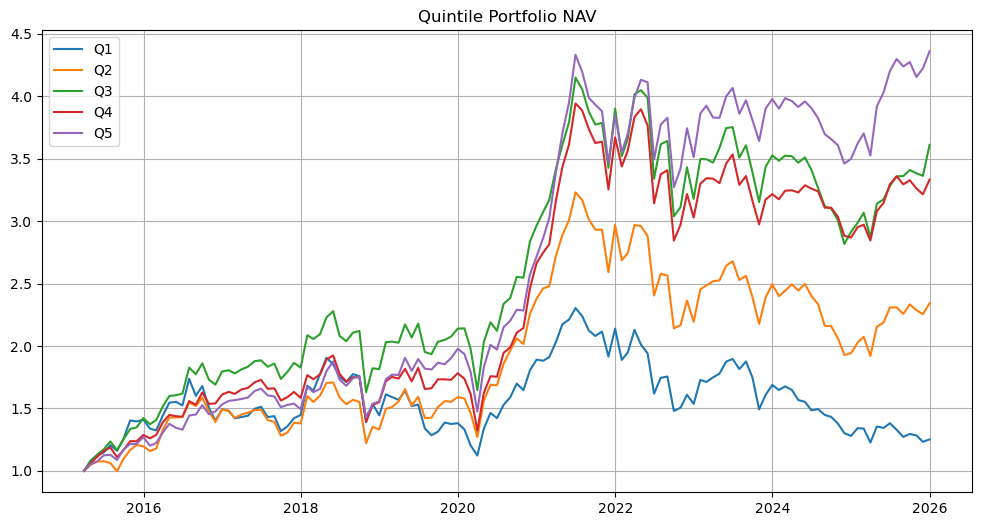

In [54]:
# ====================================================
# 분위수별 NAV 그래프
# ====================================================
plt.figure(figsize=(12, 6))
for q in range(1, 6):
    plt.plot(quintile_nav.index, quintile_nav[f"Q{q}"], label=f"Q{q}")
plt.title("Quintile Portfolio NAV")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
# ====================================================
# 분위수별 성과표
# ====================================================
def calc_perf_stats(ret_s: pd.Series):
    ret_s = ret_s.dropna()
    if len(ret_s) == 0:
        return {
            "CAGR": np.nan,
            "Ann.Vol": np.nan,
            "Sharpe": np.nan,
            "MDD": np.nan,
            "Avg.Monthly.Return": np.nan,
            "Months": 0
        }

    nav = (1 + ret_s).cumprod()
    n_months = len(ret_s)

    cagr = nav.iloc[-1] ** (12 / n_months) - 1
    ann_vol = ret_s.std() * np.sqrt(12)
    sharpe = (ret_s.mean() * 12) / ann_vol if ann_vol != 0 else np.nan
    mdd = (nav / nav.cummax() - 1).min()

    return {
        "CAGR": cagr,
        "Ann.Vol": ann_vol,
        "Sharpe": sharpe,
        "MDD": mdd,
        "Avg.Monthly.Return": ret_s.mean(),
        "Months": n_months
    }

quintile_perf = pd.DataFrame({
    f"Q{q}": calc_perf_stats(quintile_ret[q])
    for q in range(1, 6)
}).T

display(quintile_perf)

,CAGR,Ann.Vol,Sharpe,MDD,Avg.Monthly.Return,Months
Q1,0.020949,0.230342,0.205549,-0.467566,0.003946,130.0
Q2,0.081719,0.230455,0.456886,-0.405780,0.008774,130.0
Q3,0.125822,0.225886,0.641033,-0.321088,0.012067,130.0
Q4,0.117518,0.213352,0.630487,-0.312883,0.011210,130.0
Q5,0.145590,0.208410,0.759625,-0.253863,0.013193,130.0


,Q5-Q1
2025-08-31,0.028903
2025-09-30,-0.010080
2025-10-31,-0.018817
2025-11-30,0.055648
2025-12-31,0.017464


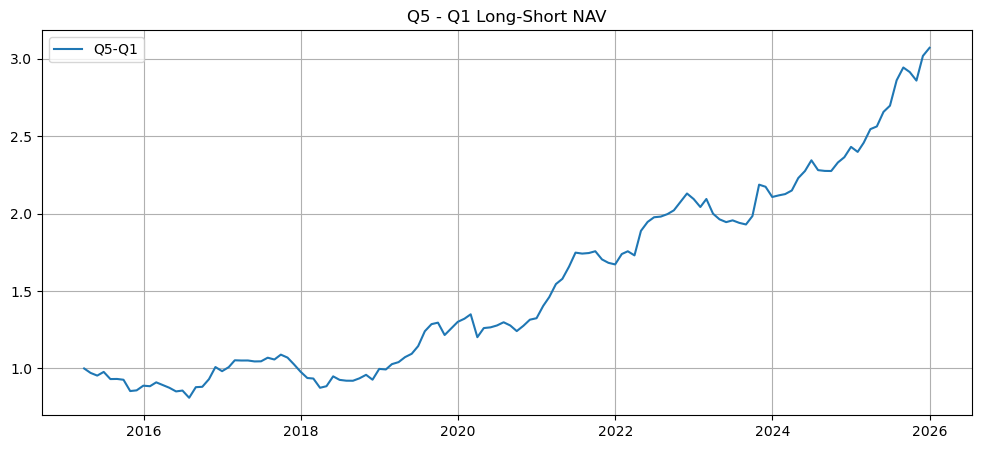

CAGR                    0.109119
Ann.Vol                 0.118661
Sharpe                  0.935157
MDD                    -0.196449
Avg.Monthly.Return      0.009247
Months                130.000000
Name: Q5-Q1, dtype: float64

In [56]:
# ====================================================
# Q5 - Q1 스프레드 수익률
# ====================================================
q5_q1_ret = quintile_ret[5].sub(quintile_ret[1], fill_value=0.0)
q5_q1_nav = (1 + q5_q1_ret.fillna(0)).cumprod()

display(q5_q1_ret.to_frame("Q5-Q1").tail())

plt.figure(figsize=(12, 5))
plt.plot(q5_q1_nav.index, q5_q1_nav, label="Q5-Q1")
plt.title("Q5 - Q1 Long-Short NAV")
plt.legend()
plt.grid(True)
plt.show()

q5_q1_perf = pd.Series(calc_perf_stats(q5_q1_ret), name="Q5-Q1")
display(q5_q1_perf)

___

In [57]:
factors = pd.read_csv("Factor.csv",index_col=0,parse_dates=True)
factors = factors['2015-03-31':'2025-12-31']
factors

,SMB,HML,MOM,KOSPI,RF
Date,,,,,
2015-03-31,116.91,1241.45,227.59,2041.03,1.85
2015-04-30,118.32,1244.60,231.80,2127.17,1.80
2015-05-31,126.02,1177.00,250.52,2114.80,1.80
2015-06-30,130.02,1156.37,272.49,2074.20,1.65
2015-07-31,132.99,1144.50,280.19,2030.16,1.64
...,...,...,...,...,...
2025-08-31,113.48,1975.48,224.41,3186.01,2.53
2025-09-30,109.13,1915.72,224.84,3424.60,2.57
2025-10-31,92.91,1824.08,227.66,4107.50,2.55


In [58]:
factors = pd.read_csv("Factor.csv", index_col=0,parse_dates=True)

In [59]:
import statsmodels.api as sm

def make_ff_factors(factors, freq="D", annual_rf=True):
    """
    factors: DataFrame with columns ['KOSPI','SMB','HML','MOM','RF']
    freq: 'D' (일간) 또는 'M' (월간)
    """
    
    df = factors.copy()

    # 0. resampling
    if freq == "M":
        df = df.resample('ME').last()
    
    # 1. 지수 → 수익률 변환
    ret_cols = ['KOSPI','SMB','HML','MOM']
    df[ret_cols] = df[ret_cols].pct_change()
    
    # 2. 무위험금리 변환 (연율 → 일/월 수익률)
    df['RF'] = df['RF'] / 100  # % → 소수화 (예: 3.5% → 0.035)
    
    if freq == "D":
        trading_days = 252
        df['RF'] = (1 + df['RF']) ** (1/trading_days) - 1
    elif freq == "M":
        df['RF'] = (1 + df['RF']) ** (1/12) - 1
    
    # 4. 컬럼 정리
    df = df[['KOSPI','SMB','HML','MOM','RF']].dropna()
    
    return df

In [60]:
ff_monthly = make_ff_factors(factors, freq="M")

In [61]:
# portfolio_ret = cap_portfolio_ret
portfolio_ret = portfolio_ret
portfolio_ret.name = "Portfolio"

# 1. 두 데이터 공통 구간 맞추기
df = pd.concat([portfolio_ret, ff_monthly], axis=1, join="inner").dropna()

# 2. 종속변수: 포트폴리오 초과수익률
y = df[portfolio_ret.name] - df['RF']

# 3. 독립변수: MKT, SMB, HML, MOM
X = pd.DataFrame({
    "MKT": df['KOSPI'] - df['RF'],
    "SMB": df['SMB'],
    "HML": df['HML'],
    "MOM": df['MOM']
}, index=df.index)

X = sm.add_constant(X, has_constant='add')

# 4. OLS 회귀
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})  # Newey-West 표준오차
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     90.60
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           5.50e-36
Time:                        15:23:38   Log-Likelihood:                 296.69
No. Observations:                 130   AIC:                            -583.4
Df Residuals:                     125   BIC:                            -569.0
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0085      0.002      5.547      0.0